> **Purpose:** Partition imbalance η per tree, for the two operators, on 1000 Kingman + 1000 birth–death trees. Which split each operator picks, and whether it is a real tree edge.
> **Data:** generated (Kingman and birth–death, n=1000, L=10⁴)

# η by operator and tree model

Two thousand trees — 1000 Kingman, 1000 birth–death — each with `n = 1000` leaves and
`L = 10⁴` sites. For each tree, read a bipartition off each operator and record:

| | vector | rule |
|---|---|---|
| **`L(S)`** | Fiedler of `Deg(S) − S` | k-means on the entries |
| **`B`** | leading-\|λ\| eigenvector of `H D H`, `D = −log S` | sign |

- **η** = larger clan / smaller clan. η = 1 is a perfectly even split; η = 999 is one leaf
  against the rest.
- **valid** = the partition is a genuine single-edge bipartition of the true tree. An
  operator that returns a *stable* split which is not an edge has recovered nothing.

Birth–death trees are far more imbalanced than Kingman trees, which is where the validity
gate has a chance to bind.

Compute is `analysis/utils/eta_screen.py` (~15 min per model on 6 workers, cached and
resumable); this notebook loads the caches and plots.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedFormatter, FixedLocator

_root = Path.cwd()
while not (_root / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

from analysis.utils.eta_screen import run_eta_screen
from src.utils.tree_ids import build_ids

N, SEQ_LEN, COUNT = 1000, 10_000, 1000
MODELS = [("kingman", "Kingman"), ("bd", "birth-death")]
ARMS = [("S", r"$L(S)$, k-means"), ("B", r"$B=H\mathcal{D}H$, sign")]
CDIR = _root / "analysis" / "notebooks_cache" / "eta_by_operator"

frames = []
for model, _ in MODELS:
    ids = build_ids(models=[model], n_values=[N], per_cell=COUNT)
    rows = run_eta_screen(ids, CDIR / f"{model}_n{N}_L{SEQ_LEN}.npz",
                          seq_len=SEQ_LEN, workers=6)
    f = pd.DataFrame([r for r in rows if "error" not in r])
    f["model"] = model
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
print(f"\n{len(df)} trees total, n={N}, L={SEQ_LEN}")
df.groupby("model").size()

cache: 1000 rows in kingman_n1000_L10000.npz
nothing to do -- all ids cached
cache: 1000 rows in bd_n1000_L10000.npz
nothing to do -- all ids cached

2000 trees total, n=1000, L=10000


model
bd         1000
kingman    1000
dtype: int64

In [2]:
summary = []
for model, mname in MODELS:
    d = df[df.model == model]
    for tag, aname in ARMS:
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        summary.append({
            "model": mname, "operator": aname,
            "valid": f"{int(v.sum())}/{len(d)}",
            "valid %": round(100 * v.mean(), 1),
            "median eta": round(float(e.median()), 2),
            "90th pct": round(float(e.quantile(0.90)), 1),
            "max eta": round(float(e.max()), 1),
        })
pd.DataFrame(summary).set_index(["model", "operator"])

valid  valid %  median eta  90th pct  \
model       operator                                                           
Kingman     $L(S)$, k-means          996/1000     99.6        3.00      20.8   
            $B=H\mathcal{D}H$, sign  986/1000     98.6        1.85       4.6   
birth-death $L(S)$, k-means          996/1000     99.6        3.08      25.4   
            $B=H\mathcal{D}H$, sign  555/1000     55.5        1.53       2.8   

                                     max eta  
model       operator                          
Kingman     $L(S)$, k-means            499.0  
            $B=H\mathcal{D}H$, sign     24.6  
birth-death $L(S)$, k-means            999.0  
            $B=H\mathcal{D}H$, sign      5.3

## What the two operators actually read

The screen keeps scalars only, so this cell rebuilds **one** tree (`make_generated` is
deterministic in the tree id) and draws it **twice** — once per operator — with its
eigenvector alongside. Each copy is the same tree, laid out from its own patristic
distances; what changes is the colouring, which is the split that operator read off. A
clade is blue or orange when every leaf below it falls on one side, grey when it straddles
the cut, so a partition is a real tree edge exactly when the grey reduces to a single path
to the root.

`TREE_ID = None` picks the Kingman tree with the largest disagreement; set it to any
`df.tree` value to look at another. Diagnostic — writes no figure asset.

In [ ]:
# The screen above stores scalars only, so rebuild ONE tree and look at the two
# vectors the two arms actually read. make_generated is deterministic in the id,
# and every step below mirrors screen_one() in analysis/utils/eta_screen.py.
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

from analysis.utils.eta_screen import MIN_SPLIT, _eta
from src.core.utils import compute_fiedler_from_laplacian, compute_laplacian
from src.models.generated_trees import make_generated
from src.runners.p_sweep_inner import _kmeans_bipartition
from src.utils.griffing import griffing_centered, griffing_leading_eigvec
from src.utils.operator_comparison import patristic_distance_matrix
from src.utils.partition_validity import check_partition_valid_in_tree
from src.utils.screening import _tree_leaf_index

TREE_ID = None                       # None -> the Kingman tree where the two arms disagree most
COL_A, COL_B, COL_MIX = "#1d4ed8", "#d97706", "#b8bcc4"   # clan A / clan B / mixed clade


def orient(v, part):
    """Display convention: clan B (part == True) is the minority side.

    Flipping v and part together is the same bipartition, so eta and validity are
    unchanged. They MUST flip together -- for arm B the mask *is* sign(v), so for
    that arm this also puts the minority clan on the positive side.
    """
    return (-v, ~part) if part.sum() > part.size / 2 else (v, part)


def link_colors(Z, mask):
    """Colour every merge in ``Z`` by the clan of the leaves below it.

    A clade is COL_A or COL_B when all of its leaves are on one side of the
    bipartition and COL_MIX when they are not, so a partition that IS a tree edge
    shows as two monochrome subtrees joined by a single grey path to the root.
    ``mask`` must be in the linkage's own leaf order, i.e. tree-leaf order.
    """
    n_b, total, cols = list(mask.astype(int)), [1] * mask.size, {}
    for i, (a, b) in enumerate(Z[:, :2].astype(int)):
        n_b.append(n_b[a] + n_b[b])
        total.append(total[a] + total[b])
        j = i + mask.size
        cols[j] = COL_B if n_b[j] == total[j] else (COL_A if n_b[j] == 0 else COL_MIX)
    return lambda k: cols.get(k, COL_MIX)


if TREE_ID is None:
    k = df[df.model == "kingman"]
    TREE_ID = k["tree"].iloc[int(np.abs(np.log(k.eta_S / k.eta_B)).values.argmax())]
row = df[df.tree == TREE_ID].iloc[0]
print(f"{TREE_ID}:  eta_S={row.eta_S:.2f} (valid={row.valid_S})   "
      f"eta_B={row.eta_B:.2f} (valid={row.valid_B})")

S, labels, tree, D = make_generated(TREE_ID, seq_len=SEQ_LEN)
sidx = _tree_leaf_index(tree, labels)          # labels order -> tree-leaf order

v_S = compute_fiedler_from_laplacian(compute_laplacian(S))
v_S, part_S = orient(v_S, np.asarray(_kmeans_bipartition(v_S, MIN_SPLIT)).astype(bool))
v_B = griffing_leading_eigvec(D, solver="lm_k1")
v_B, part_B = orient(v_B, v_B >= 0)

# the exhibit is only worth looking at if it reproduces the screened row
for tag, part in (("S", part_S), ("B", part_B)):
    assert np.isclose(_eta(part), row[f"eta_{tag}"]), tag
    assert check_partition_valid_in_tree(tree, part[sidx]) == row[f"valid_{tag}"], tag
agree = float(np.mean(part_S == part_B))
print(f"self-check OK;  leaf-level agreement between the two splits: "
      f"{max(agree, 1 - agree):.1%}")

# Leaf order for every exhibit below: the dendrogram's, so a clan of the true tree
# is a contiguous block of rows/columns instead of scatter.
Z = hierarchy.linkage(squareform(patristic_distance_matrix(tree), checks=False),
                      method="average")
leaf_order = hierarchy.leaves_list(Z)          # tree-leaf order -> bottom-to-top on screen
perm = sidx[leaf_order]                        # labels order -> display order
n_leaf = int(v_S.size)
y = np.arange(n_leaf) * 10 + 5                 # scipy puts leaf i at 10i+5


kingman_n1000_445:  eta_S=499.00 (valid=True)   eta_B=1.02 (valid=True)
self-check OK;  leaf-level agreement between the two splits: 50.7%


### The matrices the vectors come from

`S`, its Laplacian, the distance `D = -log S` and Griffing's centred `B = HDH`, on the same tree and in the same leaf order as the plots below. **Each panel is scaled separately** -- their ranges differ by orders of magnitude, so a shared colour scale would be uninformative; the sub-title of each panel states the norm it uses.


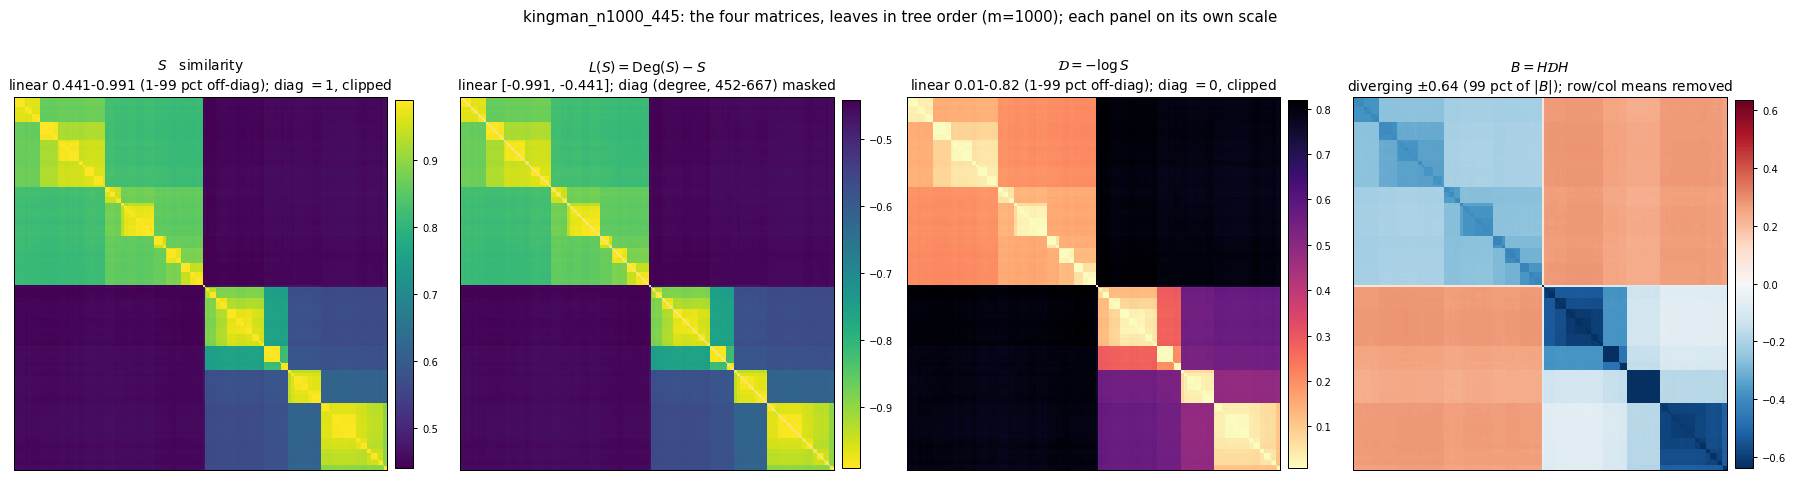

In [ ]:
# Before the vectors: the four operators themselves, same tree, same leaf order,
# so a clan of the true tree is a contiguous block. Each panel gets its OWN norm --
# S lives in (0, 1], L's diagonal is O(m) while its off-diagonal is in [-1, 0], D is
# a distance and B is signed and doubly centred. On one shared scale three of the
# four would be a flat square; the point here is what each operator looks like, not
# how they compare in magnitude.
from matplotlib.colors import Normalize

L_S = compute_laplacian(S)
B_mat = griffing_centered(D)
m = S.shape[0]
off = ~np.eye(m, dtype=bool)
deg = L_S.diagonal()

# L's diagonal is the degree, two to three orders of magnitude above every other
# entry; drawn on one scale it turns the whole panel into a red line on white. Mask
# it, scale the rest, and report the degree range in the sub-title instead.
L_off = np.where(off, L_S, np.nan)
lo_S, hi_S = np.percentile(S[off], [1, 99])
lo_D, hi_D = np.percentile(D[off], [1, 99])
lo_L, hi_L = np.percentile(L_S[off], [1, 99])
vmax_B = float(np.percentile(np.abs(B_mat), 99))

panels = [
    ("S", S, r"$S$   similarity",
     f"linear {lo_S:.3f}-{hi_S:.3f} (1-99 pct off-diag); diag $=1$, clipped",
     "viridis", Normalize(lo_S, hi_S)),
    ("L", L_off, r"$L(S) = \mathrm{Deg}(S) - S$",
     f"linear [{lo_L:.3f}, {hi_L:.3f}]; diag (degree, {deg.min():.0f}-{deg.max():.0f}) masked",
     "viridis_r", Normalize(lo_L, hi_L)),
    ("D", D, r"$\mathcal{D} = -\log S$",
     f"linear {lo_D:.2f}-{hi_D:.2f} (1-99 pct off-diag); diag $=0$, clipped",
     "magma_r", Normalize(lo_D, hi_D)),
    ("B", B_mat, r"$B = H\mathcal{D}H$",
     f"diverging $\\pm${vmax_B:.2f} (99 pct of $|B|$); row/col means removed",
     "RdBu_r", Normalize(-vmax_B, vmax_B)),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5.6))
for ax, (key, A, name, how, cmap, norm) in zip(axes, panels):
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad("#e5e7eb")                      # the masked diagonal of L
    im = ax.imshow(A[np.ix_(perm, perm)], cmap=cm, norm=norm,
                   interpolation="nearest", origin="upper")
    ax.set_title(f"{name}\n{how}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).ax.tick_params(labelsize=8)
fig.suptitle(f"{TREE_ID}: the four matrices, leaves in tree order "
             f"(m={m}); each panel on its own scale", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# L's off-diagonal is exactly -S, so the only thing the Laplacian adds to the
# similarity is on the diagonal: the degree, which is the row sum of S.
for key, A, *_ in panels:
    d = A[off]
    print(f"{key:>2s}  min={np.nanmin(A):+.4g}  max={np.nanmax(A):+.4g}  "
          f"off-diag mean={np.nanmean(d):+.4g}  sd={np.nanstd(d):.4g}")


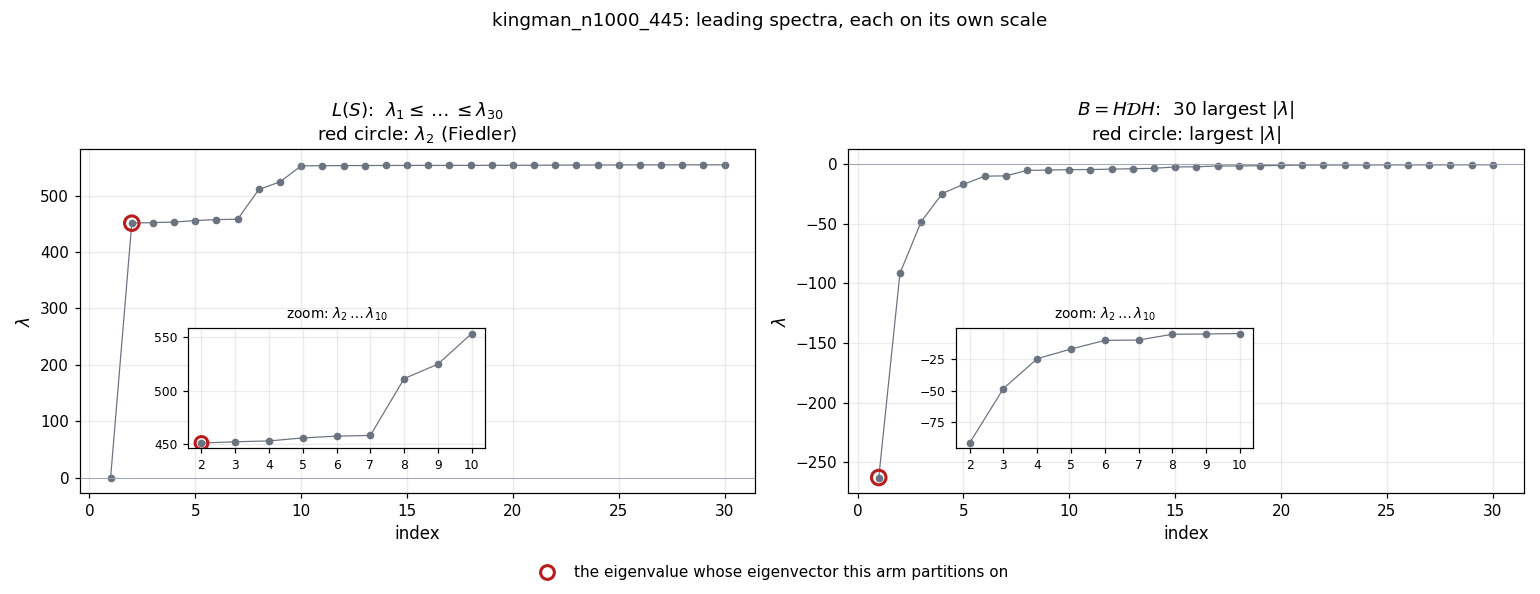

In [ ]:
# The signal each arm actually has to work with: the first 50 eigenvalues of the two
# operators, ordered the way the arm reads them -- L(S) ascending (it wants the 2nd
# smallest, the Fiedler value) and B by |lambda| descending (it wants the largest,
# which for a raw distance matrix is the most negative). Two separate scales again:
# L(S) is PSD with a hard zero at index 1, B is negative semi-definite.
import scipy.linalg
from matplotlib.lines import Line2D

K = 50                                          # eigenvalues computed
K_PLOT = 30                                     # eigenvalues drawn
ev_L = scipy.linalg.eigvalsh(L_S, subset_by_index=[0, K - 1])          # ascending
ev_B = scipy.linalg.eigvalsh(B_mat)
ev_B = ev_B[np.argsort(-np.abs(ev_B))][:K]                             # |lambda| descending

# Both panels zoom on indices 2..10: for L(S) that is the Fiedler value and the gap
# above it, for B it is the tail the leading eigenvalue has to stand out from.
ZOOM = (1, 10)                                   # 0-based slice -> indices 2..10

# (values, index of the entry the arm uses, panel title, what the red circle marks)
spectra = [
    (ev_L, 1, rf"$L(S)$:  $\lambda_1 \leq \dots \leq \lambda_{{{K_PLOT}}}$",
     r"$\lambda_2$ (Fiedler)"),
    (ev_B, 0, rf"$B = H\mathcal{{D}}H$:  {K_PLOT} largest $|\lambda|$",
     r"largest $|\lambda|$"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (ev, used, name, note) in zip(axes, spectra):
    ev, idx = ev[:K_PLOT], np.arange(1, K_PLOT + 1)
    ax.plot(idx, ev, "o-", ms=4, lw=0.8, color="#6b7280", zorder=1)
    ax.scatter([idx[used]], [ev[used]], s=90, facecolor="none",
               edgecolor="#b91c1c", lw=2, zorder=3)
    ax.axhline(0, color="#9ca3af", lw=0.6)
    ax.set_title(f"{name}\nred circle: {note}", fontsize=12)
    ax.set_xlabel("index", fontsize=11)
    ax.set_ylabel(r"$\lambda$", fontsize=11)
    ax.grid(alpha=0.25)

    # lambda_1 = 0 and the bulk sit orders of magnitude away from the gaps that
    # matter, so the head of each spectrum needs its own axis to be readable.
    a, b = ZOOM
    axi = ax.inset_axes([0.16, 0.13, 0.44, 0.35])    # same corner in every panel
    axi.plot(idx[a:b], ev[a:b], "o-", ms=4, lw=0.8, color="#6b7280")
    if a <= used < b:                            # B's leading value is outside the zoom
        axi.scatter([idx[used]], [ev[used]], s=70, facecolor="none",
                    edgecolor="#b91c1c", lw=2, zorder=3)
    axi.set_title(rf"zoom: $\lambda_{{{a+1}}}\dots\lambda_{{{b}}}$", fontsize=9)
    axi.set_xticks(np.arange(a + 1, b + 1))   # integer indices, not 2.5
    axi.tick_params(labelsize=8)
    axi.grid(alpha=0.25)

fig.legend([Line2D([], [], ls="none", marker="o", ms=9, mfc="none",
                   mec="#b91c1c", mew=2)],
           ["the eigenvalue whose eigenvector this arm partitions on"],
           loc="lower center", fontsize=10, frameon=False)
fig.suptitle(f"{TREE_ID}: leading spectra, each on its own scale", fontsize=12)
fig.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()

# The gap next to the eigenvector each arm uses is the whole story of how stable that
# split is: a small relative gap means sub-sampling can rotate the vector out of it.
gap_L = (ev_L[2] - ev_L[1]) / ev_L[2] if ev_L[2] > 0 else np.nan
gap_B = (abs(ev_B[0]) - abs(ev_B[1])) / abs(ev_B[0])
print(f"L(S): lambda_1..4  = {np.array2string(ev_L[:4], precision=4)}   "
      f"relative gap (l3-l2)/l3 = {gap_L:.4f}")
print(f"B   : |lambda|_1..4 = {np.array2string(np.abs(ev_B[:4]), precision=4)}   "
      f"relative gap = {gap_B:.4f}")


### Is that one tree representative?

The exhibit above is the **maximum-disagreement** tree in the Kingman pool (`argmax |log(eta_S / eta_B)|`), so it is by construction the least typical tree there is. This cell redraws the same two spectra for 100 random trees per model and asks whether the shape survives: is `L(S)` routinely near-degenerate at `lambda_2`, and is `B` routinely dominated by one `|lambda|`?

Cached to `notebooks_cache/eta_by_operator/`; ~2.6 s per tree, so ~9 min on a cold cache and instant afterwards.


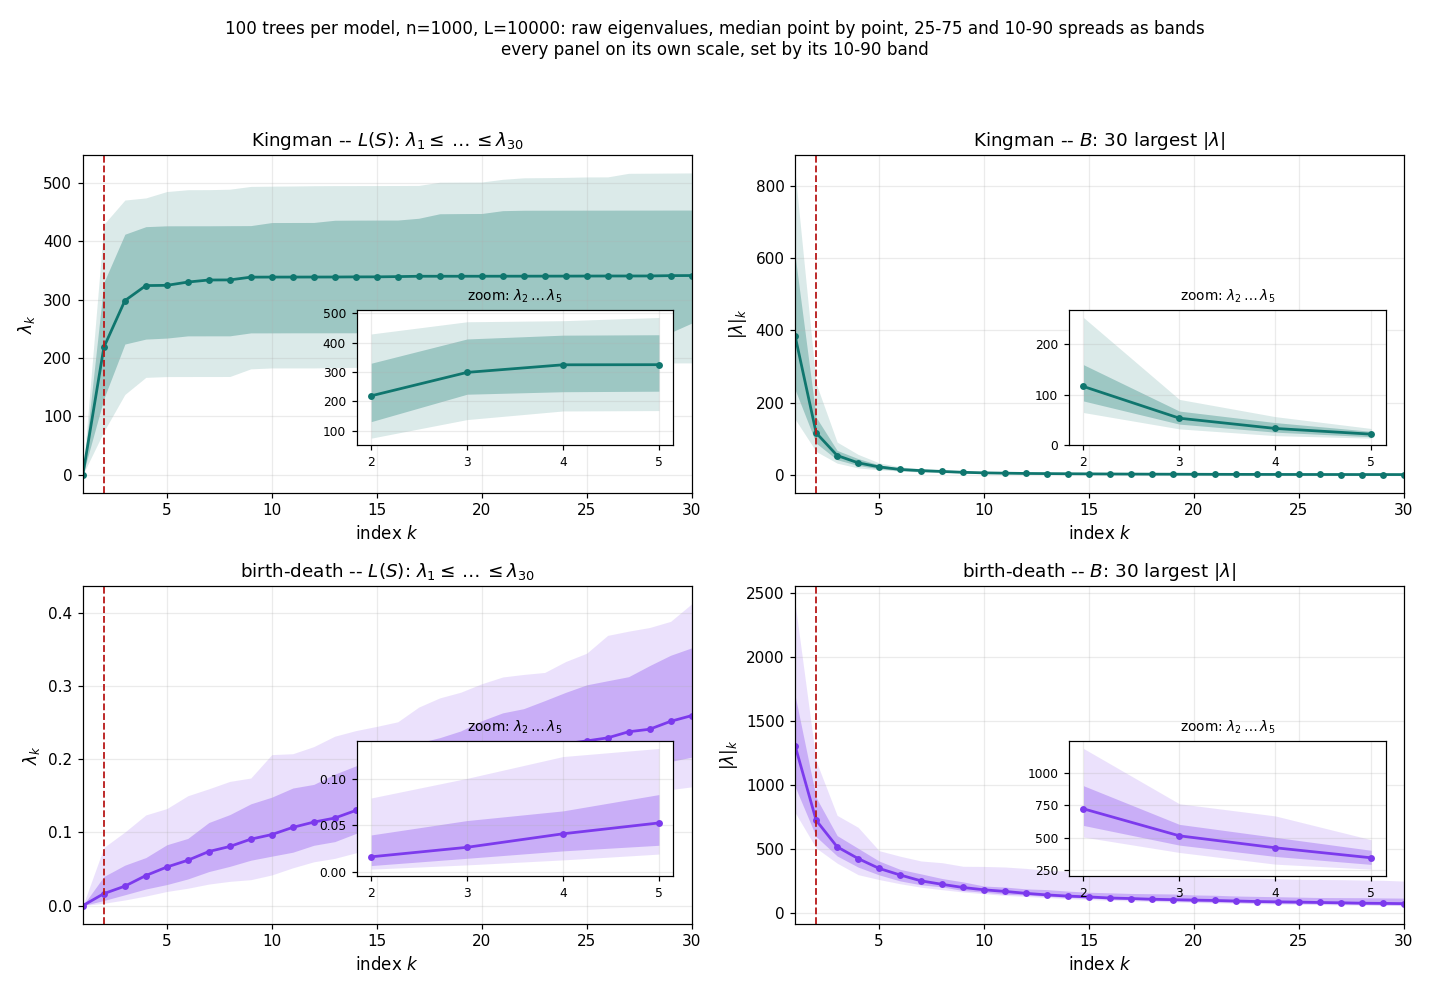

,trees,L(S) gap q25,L(S) gap med,L(S) gap q75,B gap q25,B gap med,B gap q75,B gap > L(S) gap
model,,,,,,,,
Kingman,100,0.084,0.2080,0.412,0.425,0.6310,0.798,89%
birth-death,100,0.107,0.2980,0.538,0.262,0.3800,0.554,63%
exhibit tree (kingman_n1000_445),1,NaN,0.0024,NaN,NaN,0.6513,NaN,NaN


In [ ]:
# One tree proves nothing -- and this one is the worst possible witness, being the
# argmax-disagreement tree. Recompute both spectra on a random sample from BOTH pools
# and test the two claims the single exhibit suggests:
#   (i)  L(S) is near-degenerate at lambda_2 -- the Fiedler vector is not isolated, so
#        a sub-sample can rotate it into a different split;
#   (ii) B has one |lambda| far above the rest -- its leading vector IS isolated.
R_SAMPLE = 100                                  # trees per model
SPEC_CACHE = CDIR / f"spectra_sample_n{N}_L{SEQ_LEN}_R{R_SAMPLE}.npz"

rng = np.random.default_rng(0)
sample_ids = np.asarray(np.concatenate(
    [rng.choice(np.sort(df[df.model == mo]["tree"].values), R_SAMPLE, replace=False)
     for mo, _ in MODELS]), dtype="U")            # str dtype: the cache is pickle-free
models = np.repeat([mo for mo, _ in MODELS], R_SAMPLE)

cached = np.load(SPEC_CACHE, allow_pickle=False) if SPEC_CACHE.exists() else None
if cached is not None and np.array_equal(cached["ids"], sample_ids):
    spec_L, spec_B = cached["spec_L"], cached["spec_B"]
else:
    spec_L, spec_B = np.empty((sample_ids.size, K)), np.empty((sample_ids.size, K))
    for i, tid in enumerate(sample_ids):
        S_i, _, _, D_i = make_generated(str(tid), seq_len=SEQ_LEN)
        spec_L[i] = scipy.linalg.eigvalsh(compute_laplacian(S_i),
                                          subset_by_index=[0, K - 1])
        e = scipy.linalg.eigvalsh(griffing_centered(D_i))
        spec_B[i] = e[np.argsort(-np.abs(e))][:K]
        print(f"\r{i+1}/{sample_ids.size}  {tid}", end="")
    SPEC_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(SPEC_CACHE, ids=sample_ids, spec_L=spec_L, spec_B=spec_B)
    print()

# The two quantities the single exhibit made a claim about.
gapL = (spec_L[:, 2] - spec_L[:, 1]) / spec_L[:, 2]
gapB = (np.abs(spec_B[:, 0]) - np.abs(spec_B[:, 1])) / np.abs(spec_B[:, 0])
C_MOD = {"kingman": "#0f766e", "bd": "#7c3aed"}


def pad_lim(lohi, frac=0.06):
    """A y-range with a little air, so a clipped percentile band is not flush."""
    lo, hi = float(lohi[0]), float(lohi[1])
    pad = frac * (hi - lo) or 1e-12
    return lo - pad, hi + pad

# One panel per (tree model, operator): the two models' eigenvalues differ by orders
# of magnitude (Kingman similarities are far larger, so are its degrees), so putting
# them on one axis flattens birth-death onto the floor. Every panel scales itself.
kk = np.arange(1, K_PLOT + 1)
ARM_SPEC = [(spec_L[:, :K_PLOT],
             rf"$L(S)$: $\lambda_1 \leq \dots \leq \lambda_{{{K_PLOT}}}$", r"$\lambda_k$"),
            (np.abs(spec_B[:, :K_PLOT]),
             rf"$B$: {K_PLOT} largest $|\lambda|$", r"$|\lambda|_k$")]

ZOOM_SAMPLE = (1, 5)                            # this panel zooms tighter: indices 2..5


def band(ax_, x, block, color):
    """Median point by point, with the 25-75 and 10-90 spreads drawn as bands.

    100 individual curves hid the median and dragged every axis out to a handful of
    extreme trees; the bands carry the same spread and set an honest scale.
    """
    p10, q25, med, q75, p90 = np.percentile(block, [10, 25, 50, 75, 90], axis=0)
    ax_.fill_between(x, p10, p90, color=color, alpha=0.15, lw=0)
    ax_.fill_between(x, q25, q75, color=color, alpha=0.30, lw=0)
    ax_.plot(x, med, "o-", ms=3.5, lw=1.8, color=color)
    return p10.min(), p90.max()


fig, axes = plt.subplots(len(MODELS), len(ARM_SPEC), figsize=(13, 9))
for r, (mo, mname) in enumerate(MODELS):
    sel = models == mo
    for c, (Y, name, ylab) in enumerate(ARM_SPEC):
        ax, Yv = axes[r, c], Y[sel]
        ax.set_ylim(*pad_lim(band(ax, kk, Yv, C_MOD[mo])))
        ax.axvline(2, color="#b91c1c", ls="--", lw=1.2)
        ax.set_title(f"{mname} -- {name}", fontsize=12)
        ax.set_xlabel("index $k$", fontsize=11); ax.set_ylabel(ylab, fontsize=11)
        ax.set_xlim(1, K_PLOT)
        ax.grid(alpha=0.25)

        # always the same corner, and a tighter window than the single-tree exhibit
        a, b = ZOOM_SAMPLE
        axi = ax.inset_axes([0.45, 0.14, 0.52, 0.40])
        axi.set_ylim(*pad_lim(band(axi, kk[a:b], Yv[:, a:b], C_MOD[mo])))
        axi.set_title(rf"zoom: $\lambda_{{{a+1}}}\dots\lambda_{{{b}}}$", fontsize=9)
        axi.set_xticks(np.arange(a + 1, b + 1))   # integer indices, not 2.5
        axi.tick_params(labelsize=8)
        axi.grid(alpha=0.25)
fig.suptitle(f"{R_SAMPLE} trees per model, n={N}, L={SEQ_LEN}: raw eigenvalues, median "
             f"point by point, 25-75 and 10-90 spreads as bands\n"
             f"every panel on its own scale, set by its 10-90 band", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# The gap next to the eigenvector each arm reads is what makes that split stable under
# sub-sampling, so report it per tree model as quartiles over the sample.
gap_rows = []
for mo, mname in MODELS:
    sel = models == mo
    qL, qB = np.percentile(gapL[sel], [25, 50, 75]), np.percentile(gapB[sel], [25, 50, 75])
    gap_rows.append({
        "model": mname, "trees": int(sel.sum()),
        "L(S) gap q25": round(qL[0], 3), "L(S) gap med": round(qL[1], 3),
        "L(S) gap q75": round(qL[2], 3),
        "B gap q25": round(qB[0], 3), "B gap med": round(qB[1], 3),
        "B gap q75": round(qB[2], 3),
        "B gap > L(S) gap": f"{100*np.mean(gapB[sel] > gapL[sel]):.0f}%",
    })
gap_rows.append({
    "model": f"exhibit tree ({TREE_ID})", "trees": 1,
    "L(S) gap med": round((ev_L[2] - ev_L[1]) / ev_L[2], 4),
    "B gap med": round((abs(ev_B[0]) - abs(ev_B[1])) / abs(ev_B[0]), 4),
})
gap_table = pd.DataFrame(gap_rows).set_index("model")
gap_table   # gap = (l3-l2)/l3 for L(S), (|l|1-|l|2)/|l|1 for B; blank = not a sample


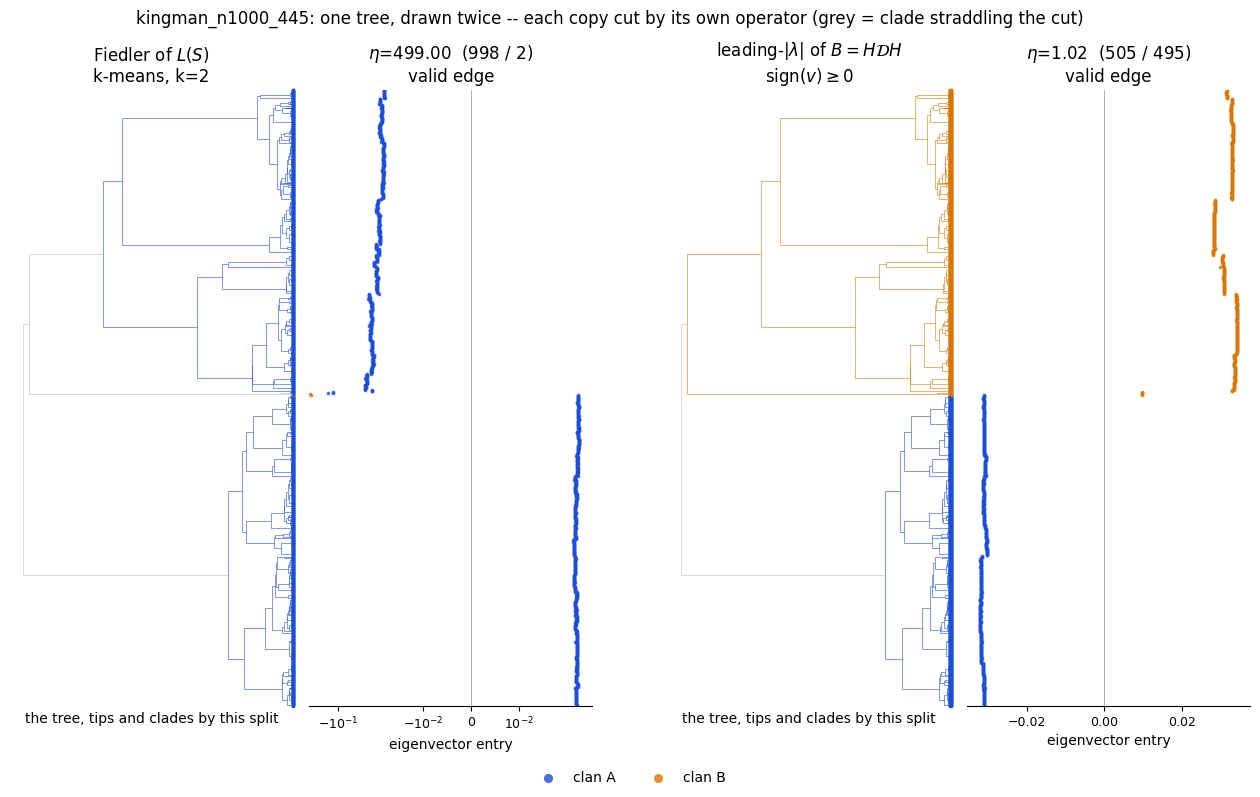

In [ ]:
# One tree, drawn twice from its own patristic distances -- once per operator, with
# every clade coloured by the split that operator read off, and its vector alongside.
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 0.15, 1, 1], wspace=0.07)
for pair, (v, part, opname, rule, tag) in zip((0, 3), [
        (v_S, part_S, r"Fiedler of $L(S)$", "k-means, k=2", "S"),
        (v_B, part_B, r"leading-$|\lambda|$ of $B=H\mathcal{D}H$", r"sign$(v)\geq 0$", "B")]):
    pt = part[sidx]                            # labels order -> tree order (linkage order)

    ax_t = fig.add_subplot(gs[pair])
    with plt.rc_context({"lines.linewidth": 0.4}):
        dendro = hierarchy.dendrogram(Z, ax=ax_t, orientation="left", no_labels=True,
                                      link_color_func=link_colors(Z, pt))
    leaf_order = np.asarray(dendro["leaves"])  # tree-leaf order -> bottom-to-top on screen
    ax_t.scatter(np.zeros(n_leaf), y, s=4, marker="s", clip_on=False,
                 c=np.where(pt[leaf_order], COL_B, COL_A))   # tip strip
    ax_t.set_ylim(0, 10 * n_leaf)
    ax_t.set_xticks([])
    ax_t.set_yticks([])
    for s in ax_t.spines.values():
        s.set_visible(False)
    ax_t.set_title(f"{opname}\n{rule}", fontsize=12)
    ax_t.set_xlabel("the tree, tips and clades by this split", fontsize=10)

    ax_v = fig.add_subplot(gs[pair + 1], sharey=ax_t)
    vv, pp = v[sidx][leaf_order], pt[leaf_order]
    for mask, col, name in ((~pp, COL_A, "clan A"), (pp, COL_B, "clan B")):
        ax_v.scatter(vv[mask], y[mask], s=7, c=col, linewidths=0, alpha=0.8, label=name)
    ax_v.axvline(0, color="#9ca3af", lw=0.6)
    ax_v.set_title(f"$\\eta$={row[f'eta_{tag}']:.2f}  "
                   f"({int((~pp).sum())} / {int(pp.sum())})\n"
                   f"{'valid edge' if row[f'valid_{tag}'] else 'NOT an edge'}", fontsize=12)
    ax_v.set_xlabel("eigenvector entry", fontsize=10)
    ax_v.tick_params(labelleft=False, labelsize=9)
    for s in ("top", "right", "left"):
        ax_v.spines[s].set_visible(False)
    # a few extreme entries would flatten the bulk onto one vertical line; symlog
    # keeps the bulk linear and compresses those into a tail, so the block
    # structure the rest of the vector carries stays visible
    lo, hi_ = np.percentile(vv, [1, 99])
    if np.ptp(vv) > 3 * (hi_ - lo):
        ax_v.set_xscale("symlog", linthresh=max(abs(lo), abs(hi_)), linscale=2.5)
    handles = ax_v.get_legend_handles_labels()

fig.legend(*handles, loc="lower center", ncol=2, fontsize=10, markerscale=2.5, frameon=False)
fig.suptitle(f"{TREE_ID}: one tree, drawn twice -- each copy cut by its own operator "
             f"(grey = clade straddling the cut)", fontsize=12)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

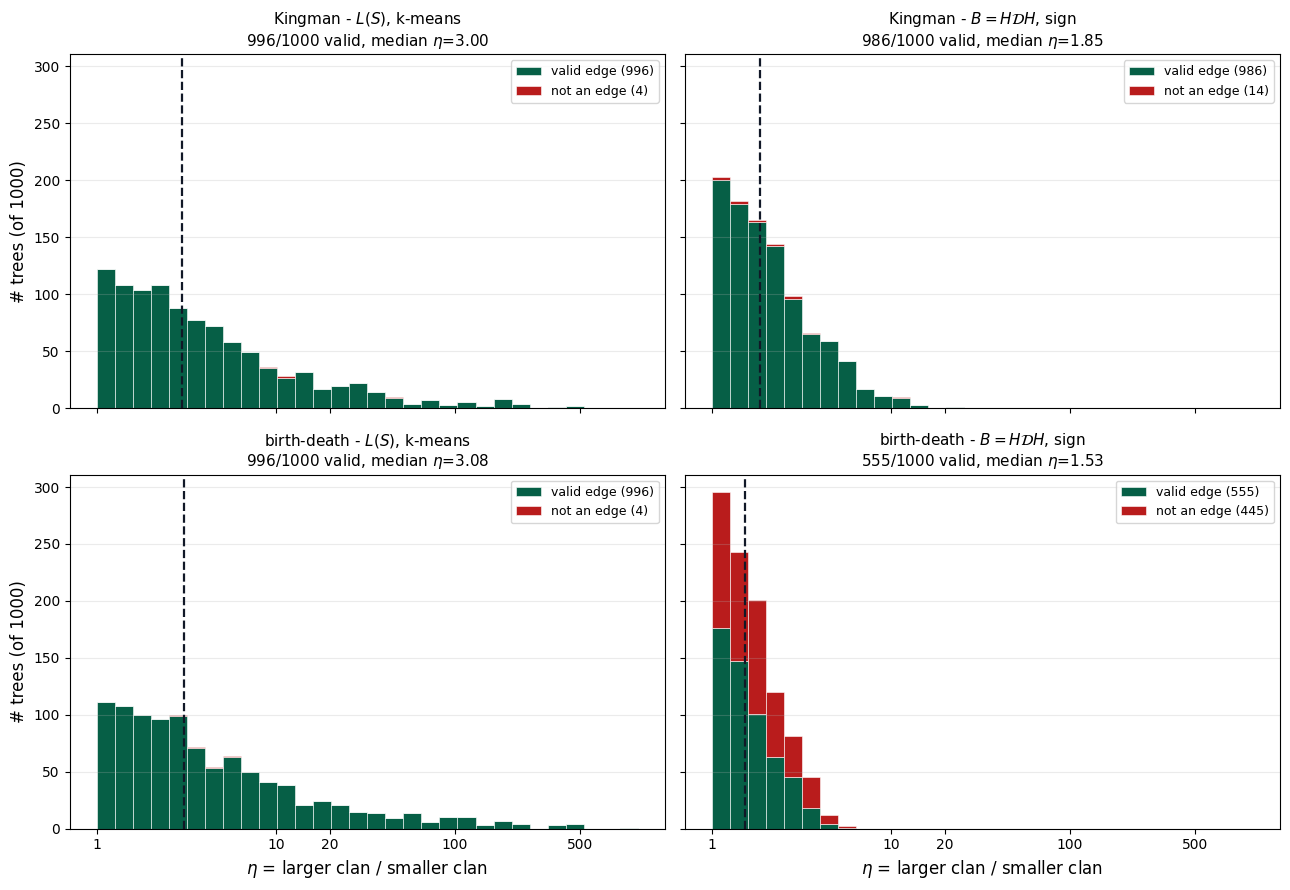

In [3]:
C_VALID, C_INVALID = "#065f46", "#b91c1c"     # green = real tree edge, red = not
XTICKS = [1, 10, 20, 100, 500]                # plain labels, not 10^k

hi = float(max(df["eta_S"].max(), df["eta_B"].max()))
bins = np.logspace(0, np.log10(hi * 1.05), 31)   # eta is a ratio spanning 1 .. ~n


def plain_log(axis, top=None):
    ticks = [t for t in XTICKS if t <= (top or hi) * 1.05]
    axis.set_major_locator(FixedLocator(ticks))
    axis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))
    axis.set_minor_locator(FixedLocator([]))


fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for r, (model, mname) in enumerate(MODELS):
    d = df[df.model == model]
    for c, (tag, aname) in enumerate(ARMS):
        ax = axes[r, c]
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        ax.hist([e[v], e[~v]], bins=bins, stacked=True,
                color=[C_VALID, C_INVALID], edgecolor="white", linewidth=0.4,
                label=[f"valid edge ({int(v.sum())})", f"not an edge ({int((~v).sum())})"])
        ax.axvline(float(e.median()), color="#111827", ls="--", lw=1.6)
        ax.set_xscale("log")
        plain_log(ax.xaxis)
        ax.set_title(f"{mname} - {aname}\n"
                     f"{int(v.sum())}/{len(d)} valid, median $\\eta$={e.median():.2f}",
                     fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25, axis="y")
        if r == 1:
            ax.set_xlabel(r"$\eta$ = larger clan / smaller clan", fontsize=12)
        if c == 0:
            ax.set_ylabel(f"# trees (of {len(d)})", fontsize=12)
fig.tight_layout()
plt.show()

In [4]:
for model, mname in MODELS:
    d = df[df.model == model]
    bs, bb = d["valid_S"], d["valid_B"]
    same = np.isclose(d["eta_S"], d["eta_B"])
    diff = d[~same]
    n_bal = int((diff["eta_B"] <= diff["eta_S"]).sum())
    print(f"--- {mname} ---")
    print(f"  both valid            : {int((bs & bb).sum()):4d}")
    print(f"  only L(S) valid       : {int((bs & ~bb).sum()):4d}")
    print(f"  only B valid          : {int((~bs & bb).sum()):4d}")
    print(f"  neither valid         : {int((~bs & ~bb).sum()):4d}")
    print(f"  same validity verdict : {100*(bs == bb).mean():.1f}%")
    print(f"  identical eta         : {100*same.mean():.1f}%  (same split picked by both)")
    print(f"  of {len(diff)} disagreements, B is the more balanced: {n_bal}/{len(diff)}")
    print()

--- Kingman ---
  both valid            :  982
  only L(S) valid       :   14
  only B valid          :    4
  neither valid         :    0
  same validity verdict : 98.2%
  identical eta         : 64.1%  (same split picked by both)
  of 359 disagreements, B is the more balanced: 355/359

--- birth-death ---
  both valid            :  553
  only L(S) valid       :  443
  only B valid          :    2
  neither valid         :    2
  same validity verdict : 55.5%
  identical eta         : 33.2%  (same split picked by both)
  of 668 disagreements, B is the more balanced: 654/668



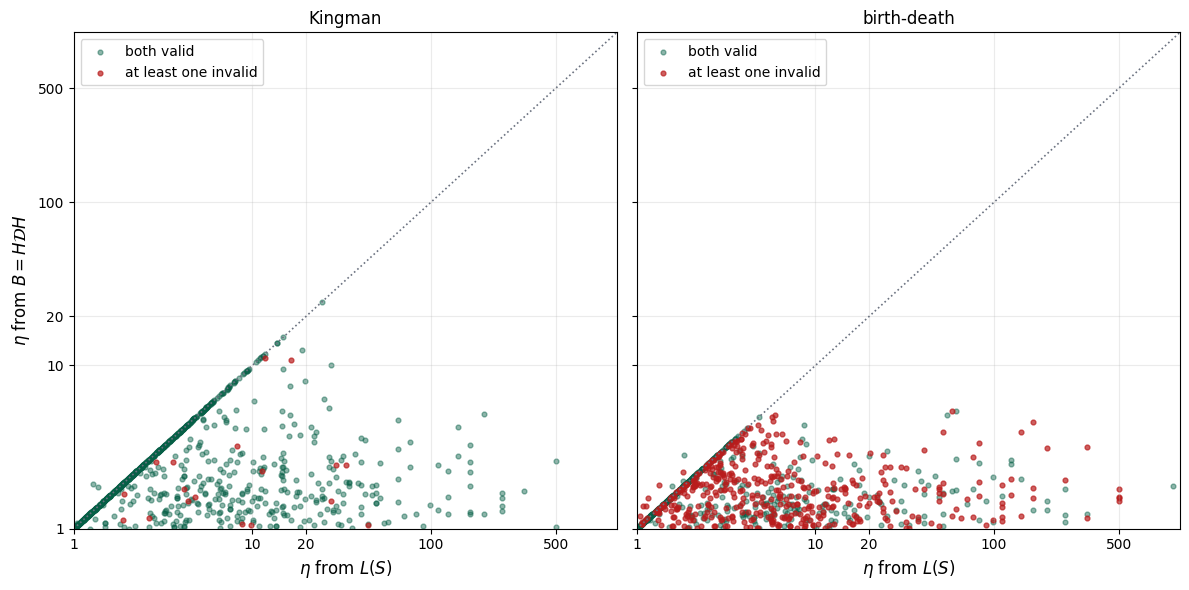

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
lim = [1, hi * 1.1]
for ax, (model, mname) in zip(axes, MODELS):
    d = df[df.model == model]
    both = d["valid_S"] & d["valid_B"]
    ax.scatter(d["eta_S"][both], d["eta_B"][both], s=12, alpha=0.45,
               color=C_VALID, label="both valid")
    ax.scatter(d["eta_S"][~both], d["eta_B"][~both], s=12, alpha=0.7,
               color=C_INVALID, label="at least one invalid")
    ax.plot(lim, lim, color="#6b7280", ls=":", lw=1.2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    plain_log(ax.xaxis); plain_log(ax.yaxis)
    ax.set_xlabel(r"$\eta$ from $L(S)$", fontsize=12)
    ax.set_title(mname, fontsize=12)
    ax.grid(alpha=0.25); ax.legend(fontsize=10)
axes[0].set_ylabel(r"$\eta$ from $B=H\mathcal{D}H$", fontsize=12)
fig.tight_layout(); plt.show()

## Paper figure

One PNG per panel, tiled in LaTeX as (a)-(d). **No matplotlib titles** — the `\subcaption`
carries model and operator. Type is sized for the printed scale: a 7in figure in a
`0.49\textwidth` subfigure is reduced ~0.46x, so anything under ~13pt lands under 6pt on
paper. All four panels share bins and axis limits, so the tails compare directly.

Set `FIG_DIR` to a scratch path to preview without overwriting the paper assets.

In [6]:
FIG_DIR = Path(os.environ.get(
    "FIG_DIR", _root / "docs" / "overleafs" / "v9" / "figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)

ymax = int(max(np.histogram(df[df.model == m][f"eta_{t}"], bins=bins)[0].max()
               for m, _ in MODELS for t, _ in ARMS) * 1.12)

for model, _ in MODELS:
    d = df[df.model == model]
    for tag, _ in ARMS:
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.hist([e[v], e[~v]], bins=bins, stacked=True,
                color=[C_VALID, C_INVALID], edgecolor="white", linewidth=0.4,
                label=[f"valid edge ({int(v.sum())})",
                       f"not an edge ({int((~v).sum())})"])
        ax.axvline(float(e.median()), color="#111827", ls="--", lw=2.2)
        ax.set_xscale("log")
        plain_log(ax.xaxis)
        ax.set_xlim(1, hi * 1.05)
        ax.set_ylim(0, ymax)
        ax.set_xlabel(r"$\eta$ = larger clan / smaller clan", fontsize=19)
        ax.set_ylabel(f"# trees (of {len(d)})", fontsize=19)
        ax.tick_params(labelsize=16)
        ax.legend(fontsize=15, loc="upper right", framealpha=0.95)
        ax.grid(alpha=0.25, axis="y")
        fig.tight_layout()
        name = f"eta_hist_{model}_{tag}.png"
        fig.savefig(FIG_DIR / name, dpi=170, bbox_inches="tight")
        plt.close(fig)
        print("wrote", name)

wrote eta_hist_kingman_S.png
wrote eta_hist_kingman_B.png


wrote eta_hist_bd_S.png
wrote eta_hist_bd_B.png


## Reading it

Rows are the tree model, columns the operator, on the *same* trees within each row. Green
is the part of each distribution that corresponds to a real tree edge; red is not an edge
and should be discounted entirely — a confident split onto a non-edge is worth nothing.

The scatter puts the two operators side by side per tree: points on the dotted diagonal
are trees where both chose the same split, points below it are trees where `B` chose the
more balanced one.